## **Brain Tumor Detection on MRI image**

### Step 1 : Collecting dataset from Kagel

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 2 : Splitting dataset and Setting the path for train and test

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

import os # for directory and file operations
import numpy as np # for numerical operations and handling image array
import random # for generating random value for augmentation
from PIL import Image,ImageEnhance # for image processing and Inhancement

# Keras
from tensorflow.keras.models import Sequential # for building the modal
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout # for modal layer
from tensorflow.keras.preprocessing.image import load_img # for loading image
from tensorflow.keras.optimizers import Adam # for optimizer
from tensorflow.keras.applications import VGG16 # for using VGG16 modal
from sklearn.utils import shuffle # for shuffling the data to improve generality

In [ ]:
# Directories for training and testing data
train_dir = '/content/drive/MyDrive/Training'
test_dir = '/content/drive/MyDrive/Testing'

In [ ]:
import tensorflow as tf
import numpy as np
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

### Step 4: Data Preprocessing

In [ ]:
# Train generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    shear_range=0.1,
    brightness_range=[0.9,1.1],
    horizontal_flip=False,
    validation_split=0.2
)

# Validation generator (NO augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=24,
    class_mode='sparse',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=24,
    subset='validation',
    class_mode='sparse'
)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.


In [ ]:
print(train_data.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


### Step 5 : CNN Architecture

In [ ]:
from tensorflow.keras import layers, models
reg = tf.keras.regularizers.l2(0.001)

model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=(224,224,3)))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(32, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2,2))

# Block 2
model.add(layers.Conv2D(64, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(64, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2,2))

# Block 3
model.add(layers.Conv2D(128, (3,3), padding='same',kernel_regularizer=reg))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(128, (3,3), padding='same',kernel_regularizer=reg))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2,2))

# Block 4
model.add(layers.Conv2D(256, (3,3), padding='same',kernel_regularizer=reg))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(256, (3,3), padding='same',kernel_regularizer=reg))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2,2))

# Block 5 (No Pooling)
model.add(layers.Conv2D(256, (3,3), padding='same',kernel_regularizer=reg))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))

# Head
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(128, activation='relu', kernel_regularizer=reg))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(4, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,16

 Total params: 1,800,612 (6.87 MB)

 Trainable params: 1,798,180 (6.86 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0811258278145695), 1: np.float64(1.0659981343283582), 2: np.float64(0.8955721003134797), 3: np.float64(0.9800600343053173)}


In [ ]:
class_weights[0] *= 1.2
class_weights[1] *= 1.2

### Step 6 : Modal Compilation

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_sparse_categorical_accuracy',
    save_best_only=True
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [ ]:
loss = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss,
    metrics=['sparse_categorical_accuracy']
)

### Step 7 : Modal Training

### Step 8 : Plot Accuracy Graph

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=35,
    callbacks=[early_stop, checkpoint, lr_scheduler],
    class_weight=class_weights
)

print("Best Validation Accuracy:", max(history.history['val_sparse_categorical_accuracy']))
print("Best Validation Loss:", min(history.history['val_loss']))

Epoch 1/35
191/191 ━━━━━━━━━━━━━━━━━━━━ 3459s 18s/step - loss: 1.6949 - sparse_categorical_accuracy: 0.6817 - val_loss: 4.5647 - val_sparse_categorical_accuracy: 0.2419 - learning_rate: 0.0010
Epoch 2/35
191/191 ━━━━━━━━━━━━━━━━━━━━ 97s 505ms/step - loss: 1.1204 - sparse_categorical_accuracy: 0.7720 - val_loss: 2.9108 - val_sparse_categorical_accuracy: 0.3365 - learning_rate: 0.0010
Epoch 3/35
191/191 ━━━━━━━━━━━━━━━━━━━━ 95s 494ms/step - loss: 0.9113 - sparse_categorical_accuracy: 0.8005 - val_loss: 2.0589 - val_sparse_categorical_accuracy: 0.4592 - learning_rate: 0.0010
Epoch 4/35
191/191 ━━━━━━━━━━━━━━━━━━━━ 95s 495ms/step - loss: 0.8361 - sparse_categorical_accuracy: 0.8125 - val_loss: 1.8045 - val_sparse_categorical_accuracy: 0.5977 - learning_rate: 0.0010
Epoch 5/35
191/191 ━━━━━━━━━━━━━━━━━━━━ 97s 508ms/step - loss: 0.7665 - sparse_categorical_accuracy: 0.8291 - val_loss: 1.2165 - val_sparse_categorical_accuracy: 0.6486 - learning_rate: 0.0010
Epoch 6/35
191/191 ━━━━━━━━━━━━━━━━

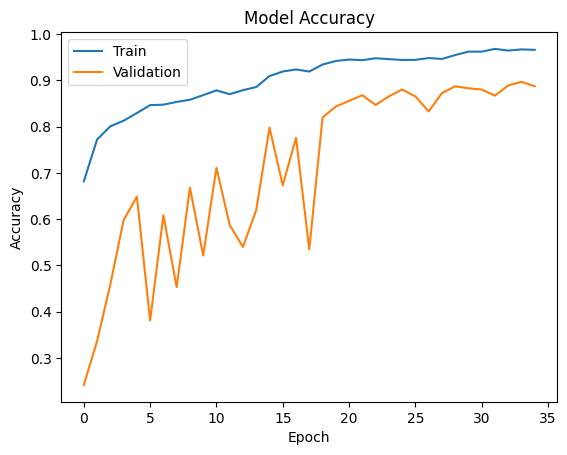

In [ ]:
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

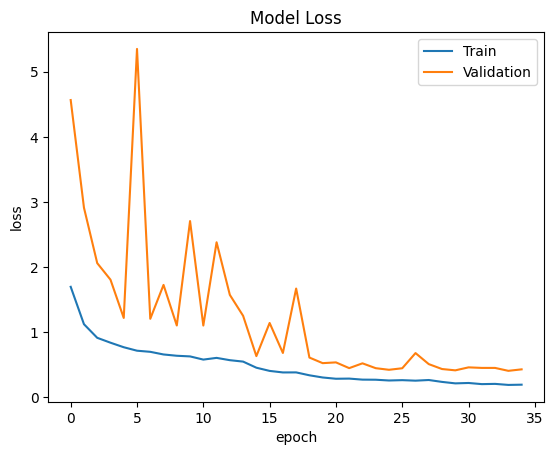

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.show()

### Step 9 : Test Data Evaluation

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Testing',
    target_size=(224, 224),
    batch_size=24,
    class_mode='sparse',
    shuffle=False
)

loss, accuracy = model.evaluate(test_data_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")

Found 1311 images belonging to 4 classes.
55/55 ━━━━━━━━━━━━━━━━━━━━ 789s 15s/step - loss: 0.2732 - sparse_categorical_accuracy: 0.9359
Test Accuracy: 93.59%


In [ ]:
from collections import Counter
print("Train:", Counter(train_data.classes))
print("Val:", Counter(val_data.classes))
print("Test:", Counter(test_data_generator.classes))

Train: Counter({np.int32(2): 1276, np.int32(3): 1166, np.int32(1): 1072, np.int32(0): 1057})
Val: Counter({np.int32(2): 319, np.int32(3): 291, np.int32(1): 267, np.int32(0): 264})
Test: Counter({np.int32(2): 405, np.int32(1): 306, np.int32(0): 300, np.int32(3): 300})


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred = model.predict(test_data_generator)
pred_classes = np.argmax(pred, axis=1)

true_classes = test_data_generator.classes

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(true_classes, pred_classes))
print(confusion_matrix(true_classes, pred_classes))

55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       300
           1       0.96      0.79      0.86       306
           2       0.94      0.99      0.96       405
           3       0.91      1.00      0.95       300

    accuracy                           0.94      1311
   macro avg       0.94      0.93      0.93      1311
weighted avg       0.94      0.94      0.93      1311

[[287   8   0   5]
 [ 15 241  25  25]
 [  2   2 400   1]
 [  0   1   0 299]]


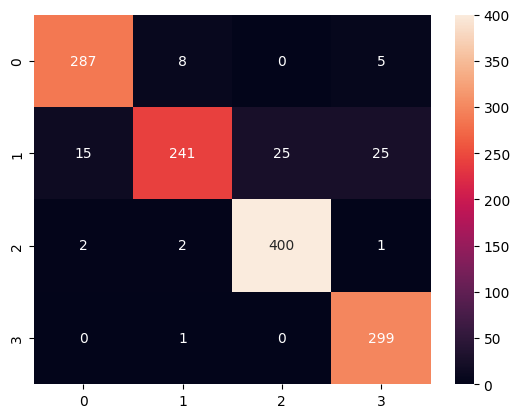

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

### Step 10 : Save Model

In [ ]:
model.save("m4fbrain4class.keras")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Te-me_0026.jpg to Te-me_0026.jpg


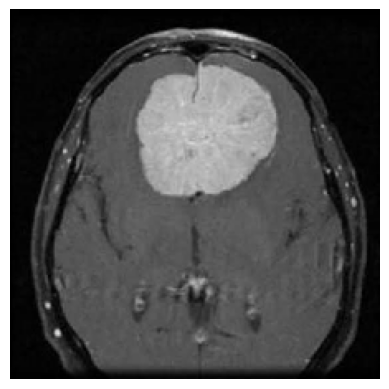

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: meningioma
Confidence: 0.9999747


In [ ]:
img_path = list(uploaded.keys())[0]

from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())
probs = prediction[0]
pred_index = np.argmax(probs)

print("Prediction:", class_names[pred_index])
print("Confidence:", probs[pred_index])